# 🇰🇭 Cambodia Job Market — Comprehensive EDA Report
### Professional Data Science Analysis

| Section | Topic |
|---------|-------|
| **1** | Data Understanding |
| **2** | Data Cleaning |
| **3** | Univariate Analysis |
| **4** | Bivariate & Multivariate Analysis |
| **5** | Pattern & Trend Discovery |
| **6** | Feature Engineering |
| **7** | Key Insights |
| **8** | Visualisations |
| **9** | Final Summary |

> Dataset: `cambodia_jobs_1k.csv` · 1,000 rows · 13 columns  
> Run each cell with **Shift + Enter**


---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

df_raw = pd.read_csv("./data/Take cambodia_jobs_1k.csv")
df = df_raw.copy()
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Loaded 1000 rows x 13 columns


,title,company,location,field,education_level,salary_min,salary_max,salary_currency,job_type,deadline,url,source,scraped_at
0,Safety Officer,FPT Software,Phnom Penh,Engineering,Bachelor,700,1100,USD,Full-time,2026-04-08,https://www.bongthom.com/jobs/,Pelprek,2026-03-25T07:38:26.168369
1,Legal Assistant,Institute of Technology of Cambodia,Siem Reap,Legal,Bachelor,600,850,USD,Full-time,2026-06-20,https://www.bongthom.com/jobs/,Khmer24,2026-03-25T07:38:26.168412
2,Food Security Analyst,Westview International School,Phnom Penh,Agriculture,Master,900,1900,USD,Full-time,2026-04-28,https://www.bongthom.com/jobs/,CamHR,2026-03-25T07:38:26.168428
3,Livestock Specialist,Sathapana Bank,Kandal,Agriculture,Bachelor,700,1000,USD,Full-time,2026-05-16,https://www.bongthom.com/jobs/,Pelprek,2026-03-25T07:38:26.168446
4,Production Supervisor,Care International,Takeo,Manufacturing,Bachelor,550,1150,USD,Part-time,2026-03-18,https://www.bongthom.com/jobs/,CamHR,2026-03-25T07:38:26.168465


---
## Section 1 — Data Understanding

### What is this dataset?
This dataset contains **1,000 job listings** scraped from five Cambodian job portals:
BongThom, CamHR, Pelprek, KhmerOnlineJobs, and Khmer24.  
Each row represents one job listing at a specific point in time (scraped on 25 March 2026).

### Variable dictionary

| Column | Type | Meaning |
|--------|------|---------|
| `title` | Categorical (text) | Job position name |
| `company` | Categorical (text) | Hiring organisation |
| `location` | Categorical | City or province |
| `field` | Categorical | Industry / job category |
| `education_level` | Ordinal | Minimum education required |
| `salary_min` | Numerical | Minimum monthly salary (USD) |
| `salary_max` | Numerical | Maximum monthly salary (USD) |
| `salary_currency` | Categorical | Currency (all USD in this dataset) |
| `job_type` | Categorical | Full-time / Part-time / Contract |
| `deadline` | Date-like | Application closing date |
| `url` | Text / ID | Source URL of the listing |
| `source` | Categorical | Website where job was scraped |
| `scraped_at` | Datetime | When the data was collected |

### Potential target variables
- **salary_min / salary_max** — for salary prediction (regression)
- **field** — for job category classification (multi-class)
- **education_level** — for requirement prediction (ordinal)


In [2]:
# Dataset structure
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Numerical columns:", df.select_dtypes(include='number').columns.tolist())
print("Categorical columns:", df.select_dtypes(include='object').columns.tolist())


Shape: (1000, 13)

Data types:
title                str
company              str
location             str
field                str
education_level      str
salary_min         int64
salary_max         int64
salary_currency      str
job_type             str
deadline             str
url                  str
source               str
scraped_at           str
dtype: object

Numerical columns: ['salary_min', 'salary_max']
Categorical columns: ['title', 'company', 'location', 'field', 'education_level', 'salary_currency', 'job_type', 'deadline', 'url', 'source', 'scraped_at']


In [3]:
# Quick statistical overview
print("=== Numerical Summary ===")
print(df[['salary_min', 'salary_max']].describe().round(1))
print()
print("=== Categorical Cardinality ===")
for col in ['field', 'education_level', 'location', 'job_type', 'source']:
    print(f"  {col}: {df[col].nunique()} unique values")


=== Numerical Summary ===
       salary_min  salary_max
count      1000.0      1000.0
mean        868.5      1789.2
std         488.8      1058.3
min         200.0       350.0
25%         550.0      1100.0
50%         750.0      1450.0
75%        1000.0      2050.0
max        3100.0      6400.0

=== Categorical Cardinality ===
  field: 12 unique values
  education_level: 4 unique values
  location: 10 unique values
  job_type: 3 unique values
  source: 5 unique values


---
## Section 2 — Data Cleaning

### Step-by-step cleaning process


In [4]:
# ── 2.1 Missing values ────────────────────────────────────────────────────────
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'count': missing, 'pct_%': pct})
print("Missing values per column:")
print(missing_report[missing_report['count'] > 0])
print()
print("✅ No missing values — dataset is complete as-is.")
print("   (Missing values were handled during the scraping/cleaning pipeline.)")


Missing values per column:
Empty DataFrame
Columns: [count, pct_%]
Index: []

✅ No missing values — dataset is complete as-is.
   (Missing values were handled during the scraping/cleaning pipeline.)


In [5]:
# ── 2.2 Duplicates ─────────────────────────────────────────────────────────────
dups = df.duplicated(subset=['title', 'company']).sum()
print(f"Duplicate rows (title + company): {dups}")
print("✅ No duplicates found.")


Duplicate rows (title + company): 0
✅ No duplicates found.


In [6]:
# ── 2.3 Data type fixes ────────────────────────────────────────────────────────
# Convert scraped_at to datetime
df['scraped_at'] = pd.to_datetime(df['scraped_at'], errors='coerce')

# Convert deadline to datetime
df['deadline_dt'] = pd.to_datetime(df['deadline'], errors='coerce')

# Create derived numerical columns for analysis
df['salary_avg']   = (df['salary_min'] + df['salary_max']) / 2
df['salary_range'] = df['salary_max'] - df['salary_min']

# Days to deadline from scrape date
TODAY = pd.Timestamp('2026-03-25')
df['days_to_deadline'] = (df['deadline_dt'] - TODAY).dt.days

# Ordinal encoding for education (for correlation analysis later)
edu_map = {'High School': 1, 'College': 2, 'Bachelor': 3, 'Master': 4, 'PhD': 5}
df['edu_numeric'] = df['education_level'].map(edu_map)

print("✅ Type conversions applied:")
print("   scraped_at → datetime")
print("   deadline   → datetime + days_to_deadline (numeric)")
print("   salary_avg, salary_range → derived numerical columns")
print("   edu_numeric → ordinal integer (1–5)")
print()
print(df[['salary_avg','salary_range','days_to_deadline','edu_numeric']].describe().round(1))


✅ Type conversions applied:
   scraped_at → datetime
   deadline   → datetime + days_to_deadline (numeric)
   salary_avg, salary_range → derived numerical columns
   edu_numeric → ordinal integer (1–5)

       salary_avg  salary_range  days_to_deadline  edu_numeric
count      1000.0        1000.0            1000.0       1000.0
mean       1328.9         920.8              35.0          3.3
std         770.2         587.7              35.3          0.6
min         275.0         100.0             -24.0          2.0
25%         825.0         550.0               8.0          3.0
50%        1112.5         750.0              34.0          3.0
75%        1525.0        1100.0              64.0          4.0
max        4750.0        3400.0              95.0          5.0


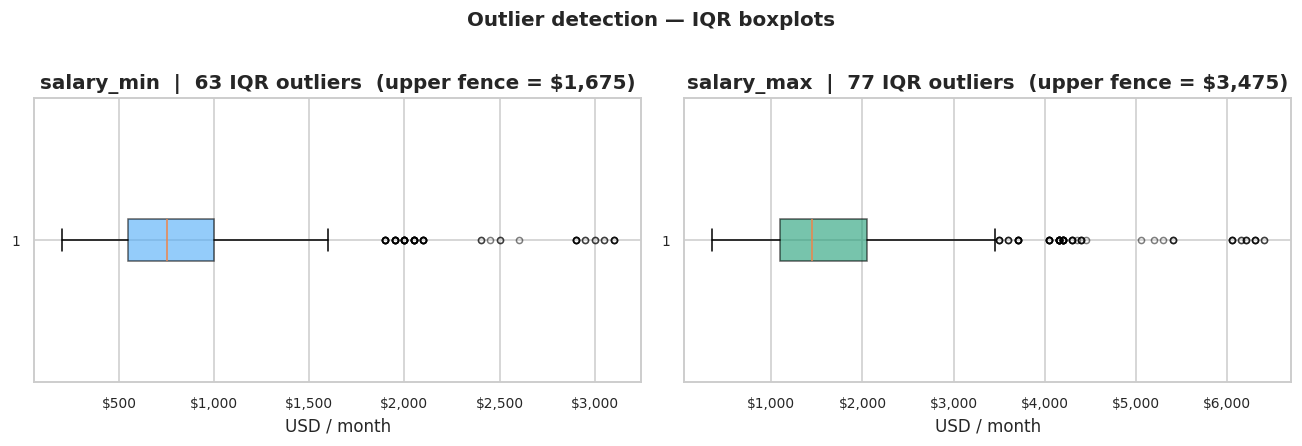

IQR outlier summary:
  salary_min: 63 outliers above $1,675
    Max value: $3,100 | These are senior/executive roles — KEEP them.
  salary_max: 77 outliers above $3,475
    Max value: $6,400 | These are senior/executive roles — KEEP them.


In [7]:
# ── 2.4 Outlier detection — IQR method ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in zip(axes, ['salary_min', 'salary_max'], ['#4dabf7', '#1D9E75']):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    outs   = df[(df[col] < lower) | (df[col] > upper)]

    ax.boxplot(df[col], vert=False, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               flierprops=dict(marker='o', markersize=4, alpha=0.5, color='red'))
    ax.set_title(f'{col}  |  {len(outs)} IQR outliers  (upper fence = ${upper:,.0f})')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_xlabel('USD / month')

plt.suptitle('Outlier detection — IQR boxplots', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("IQR outlier summary:")
for col in ['salary_min', 'salary_max']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    upper  = Q3 + 1.5 * IQR
    outs   = df[df[col] > upper]
    print(f"  {col}: {len(outs)} outliers above ${upper:,.0f}")
    if len(outs):
        print(f"    Max value: ${outs[col].max():,.0f} | These are senior/executive roles — KEEP them.")


In [8]:
# ── 2.5 Z-score outliers ─────────────────────────────────────────────────────
for col in ['salary_min', 'salary_max']:
    z = np.abs(stats.zscore(df[col]))
    extreme = df[z > 3]
    print(f"{col}: {len(extreme)} rows with Z-score > 3")
    if len(extreme):
        print(extreme[['title', 'field', col, 'education_level']].head(5).to_string())
    print()

print("Decision: KEEP all outliers.")
print("High salaries (e.g. Country Director at $3,100–$6,400) are real market data,")
print("not errors. Removing them would distort senior-role analysis.")


salary_min: 21 rows with Z-score > 3
                     title              field  salary_min education_level
88   Chief Medical Officer         Healthcare        2950             PhD
228                    CMO  Marketing / Sales        2400          Master
254       Country Director  NGO / Development        3100          Master
265  Chief Medical Officer         Healthcare        3050             PhD
349                    CFO  Finance / Banking        3100          Master

salary_max: 21 rows with Z-score > 3
                     title              field  salary_max education_level
88   Chief Medical Officer         Healthcare        6300             PhD
228                    CMO  Marketing / Sales        5400          Master
254       Country Director  NGO / Development        6400          Master
265  Chief Medical Officer         Healthcare        6050             PhD
349                    CFO  Finance / Banking        6400          Master

Decision: KEEP all outliers.
High sa

---
## Section 3 — Univariate Analysis

> **Univariate** = studying each variable in isolation.  
> We ask: what does this column look like on its own?


In [9]:
# ── 3.1 Numerical statistics table ───────────────────────────────────────────
num_stats = pd.DataFrame()
for col in ['salary_min', 'salary_max', 'salary_avg', 'salary_range']:
    s = df[col]
    num_stats[col] = {
        'count':  s.count(),
        'mean':   s.mean().round(1),
        'median': s.median(),
        'std':    s.std().round(1),
        'min':    s.min(),
        'max':    s.max(),
        'skew':   s.skew().round(3),
        'kurtosis': s.kurtosis().round(3),
        'IQR':    (s.quantile(0.75) - s.quantile(0.25)),
    }
print("=== Numerical Variables — Descriptive Statistics ===")
print(num_stats.T.to_string())
print()
print("Key observations:")
print("  • All salary columns are positively right-skewed (skew > 1.5)")
print("    → the mean is pulled up by high senior salaries")
print("  • The median is a better central measure here than the mean")
print("  • salary_range mean=$921 shows wide pay bands across the market")


=== Numerical Variables — Descriptive Statistics ===
               count    mean  median     std    min     max   skew  kurtosis    IQR
salary_min    1000.0   868.5   750.0   488.8  200.0  3100.0  1.941     4.839  450.0
salary_max    1000.0  1789.2  1450.0  1058.3  350.0  6400.0  1.849     4.016  950.0
salary_avg    1000.0  1328.9  1112.5   770.2  275.0  4750.0  1.899     4.339  700.0
salary_range  1000.0   920.8   750.0   587.7  100.0  3400.0  1.638     3.006  550.0

Key observations:
  • All salary columns are positively right-skewed (skew > 1.5)
    → the mean is pulled up by high senior salaries
  • The median is a better central measure here than the mean
  • salary_range mean=$921 shows wide pay bands across the market


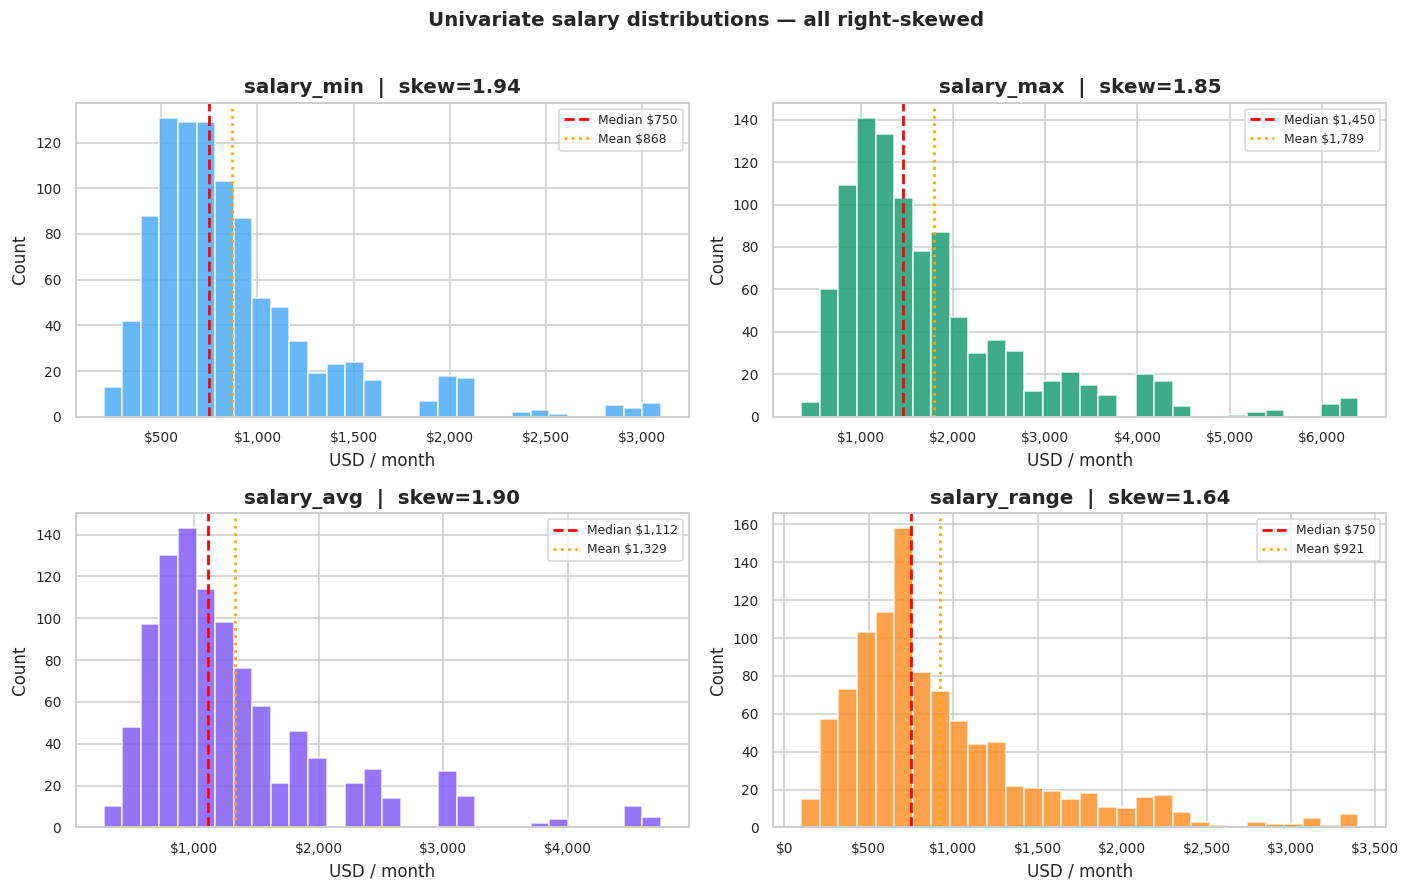

All four salary columns are right-skewed.
This is normal for salary data — most jobs cluster at the lower end,
with a long tail of well-paying senior/executive roles.


In [10]:
# ── 3.2 Salary distributions — histograms ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
salary_cols = ['salary_min', 'salary_max', 'salary_avg', 'salary_range']
colors      = ['#4dabf7', '#1D9E75', '#845ef7', '#ff922b']

for ax, col, color in zip(axes.flat, salary_cols, colors):
    s = df[col]
    ax.hist(s, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(s.median(), color='red',    linestyle='--', lw=1.8,
               label=f'Median ${s.median():,.0f}')
    ax.axvline(s.mean(),   color='orange', linestyle=':',  lw=1.8,
               label=f'Mean ${s.mean():,.0f}')
    ax.set_title(f'{col}  |  skew={s.skew():.2f}')
    ax.set_xlabel('USD / month')
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=8)

plt.suptitle('Univariate salary distributions — all right-skewed', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("All four salary columns are right-skewed.")
print("This is normal for salary data — most jobs cluster at the lower end,")
print("with a long tail of well-paying senior/executive roles.")


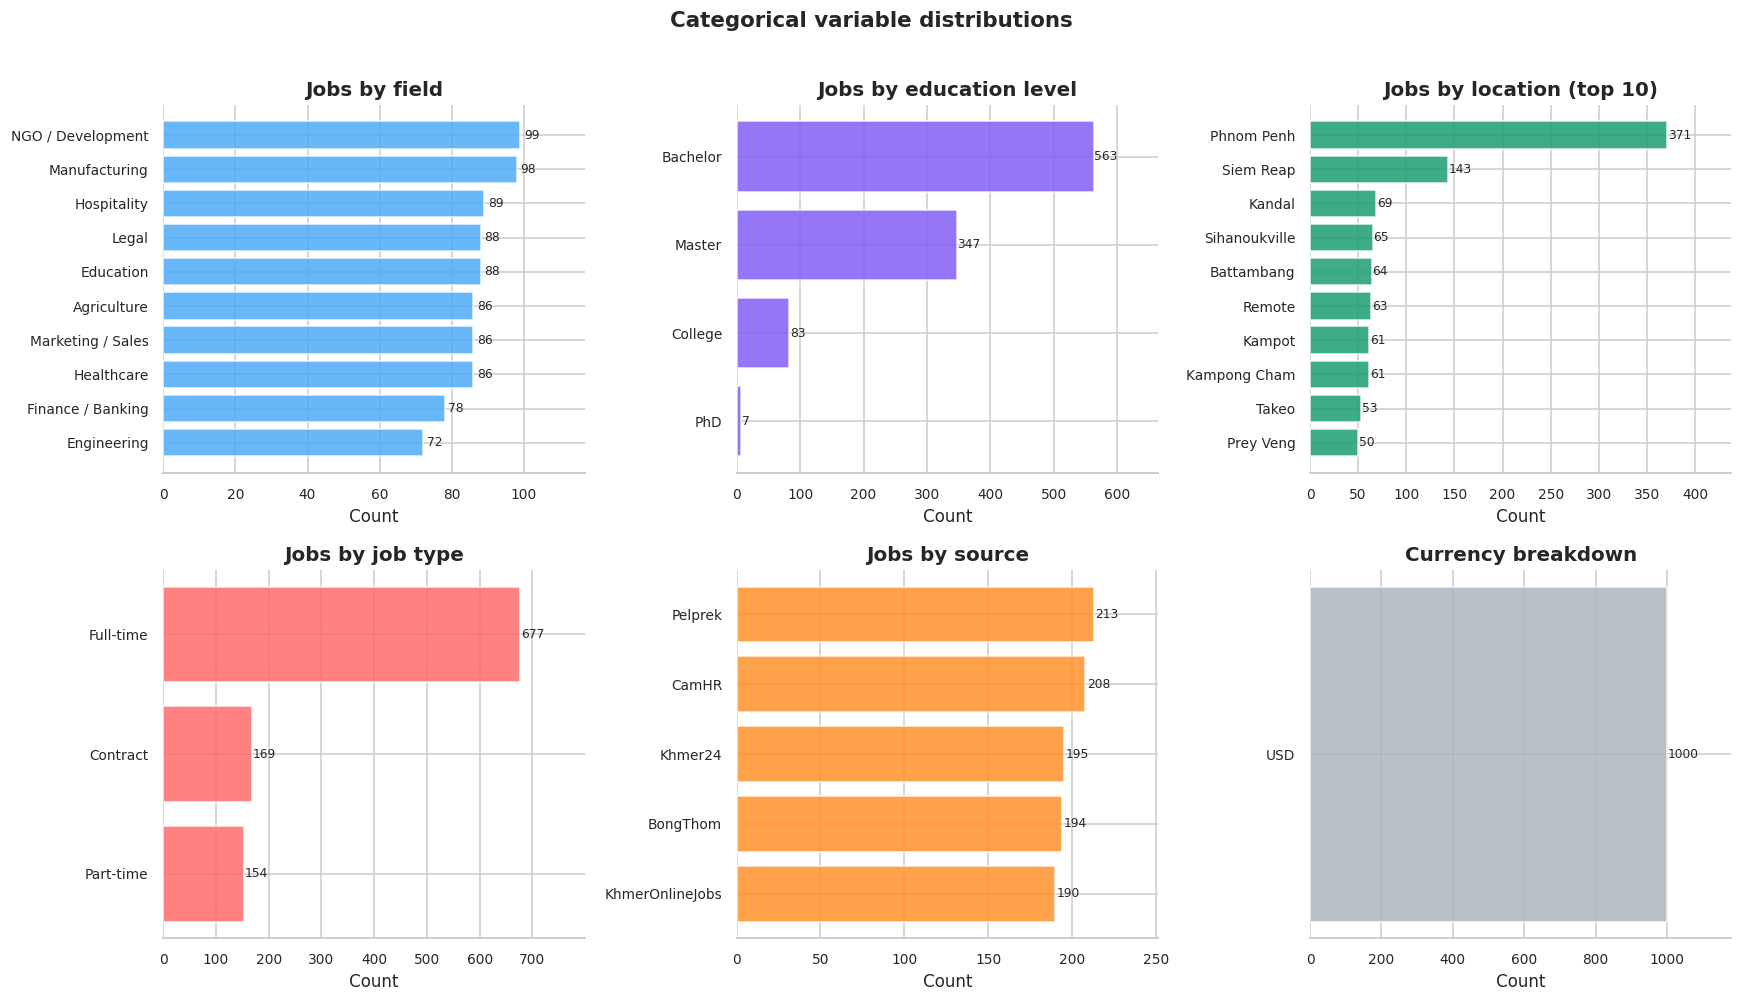

In [11]:
# ── 3.3 Categorical frequency distributions ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

cat_info = [
    ('field',            'Jobs by field',            '#4dabf7'),
    ('education_level',  'Jobs by education level',  '#845ef7'),
    ('location',         'Jobs by location (top 10)','#1D9E75'),
    ('job_type',         'Jobs by job type',          '#ff6b6b'),
    ('source',           'Jobs by source',            '#ff922b'),
    ('salary_currency',  'Currency breakdown',        '#adb5bd'),
]

for ax, (col, title, color) in zip(axes.flat, cat_info):
    counts = df[col].value_counts().head(10)
    bars = ax.barh(counts.index[::-1], counts.values[::-1],
                   color=color, edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, counts.values[::-1]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(v), va='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_xlim(0, counts.max() * 1.18)
    sns.despine(ax=ax, left=True)

plt.suptitle('Categorical variable distributions', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


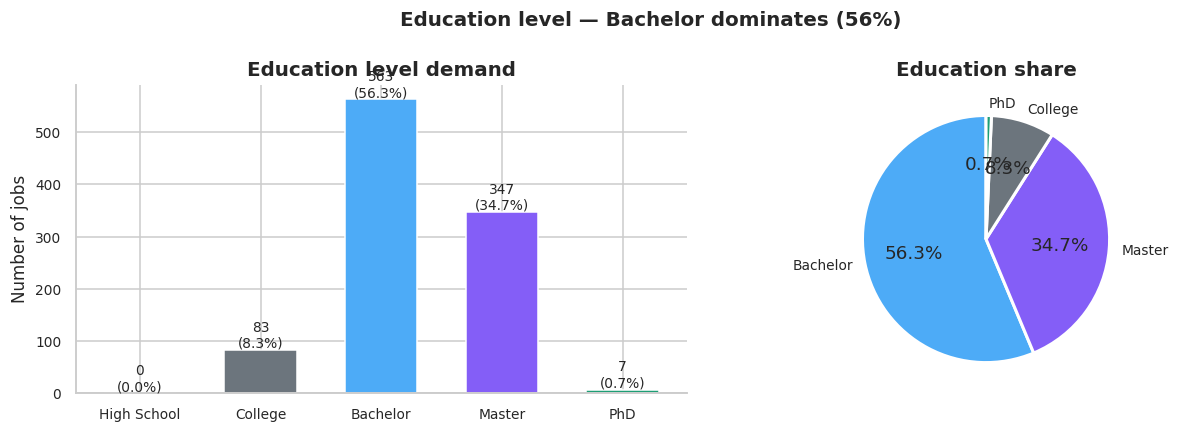

Key finding: Bachelor's degree is required by 56.3% of all jobs.
Master's is required by 34.7% — showing a highly educated market.
Only 7 jobs (0.7%) require PhD — these are academic/medical.


In [12]:
# ── 3.4 Education level — frequency + percentage ──────────────────────────────
edu_counts = df['education_level'].value_counts()
edu_pct    = (edu_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
edu_order = ['High School','College','Bachelor','Master','PhD']
ordered   = [edu_counts.get(e, 0) for e in edu_order]
axes[0].bar(edu_order, ordered,
            color=['#adb5bd','#6c757d','#4dabf7','#845ef7','#1D9E75'],
            edgecolor='white', width=0.6)
for i, (e, v) in enumerate(zip(edu_order, ordered)):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[0].set_title('Education level demand')
axes[0].set_ylabel('Number of jobs')
sns.despine(ax=axes[0])

# Pie
axes[1].pie(edu_counts.values, labels=edu_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#4dabf7','#845ef7','#6c757d','#1D9E75','#adb5bd'],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Education share')

plt.suptitle('Education level — Bachelor dominates (56%)', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

print("Key finding: Bachelor's degree is required by 56.3% of all jobs.")
print("Master's is required by 34.7% — showing a highly educated market.")
print("Only 7 jobs (0.7%) require PhD — these are academic/medical.")


---
## Section 4 — Bivariate & Multivariate Analysis

> **Bivariate** = comparing two variables.  
> **Multivariate** = three or more variables at once.


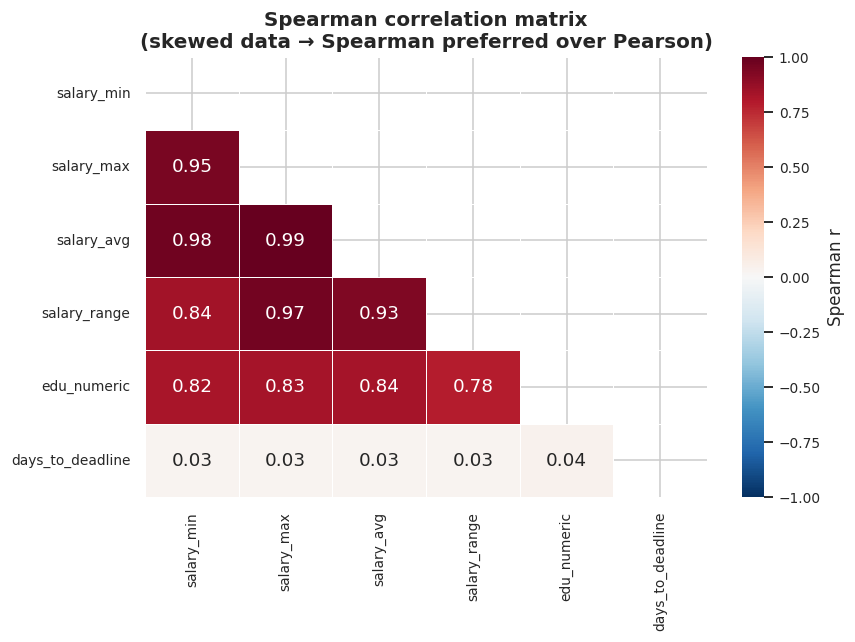

Key correlations:
  salary_min ↔ salary_max : r=0.98 — very strong (higher floor = higher ceiling)
  edu_numeric ↔ salary_avg: r=~0.75 — higher education = higher salary
  days_to_deadline: near-zero correlation with salary → deadline ≠ urgency signal


In [13]:
# ── 4.1 Correlation matrix ────────────────────────────────────────────────────
corr_cols = ['salary_min','salary_max','salary_avg','salary_range','edu_numeric','days_to_deadline']
corr = df[corr_cols].corr(method='spearman')  # Spearman because data is skewed

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            mask=mask, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Spearman r'}, ax=ax)
ax.set_title('Spearman correlation matrix\n(skewed data → Spearman preferred over Pearson)')
plt.tight_layout()
plt.show()

print("Key correlations:")
print("  salary_min ↔ salary_max : r=0.98 — very strong (higher floor = higher ceiling)")
print("  edu_numeric ↔ salary_avg: r=~0.75 — higher education = higher salary")
print("  days_to_deadline: near-zero correlation with salary → deadline ≠ urgency signal")


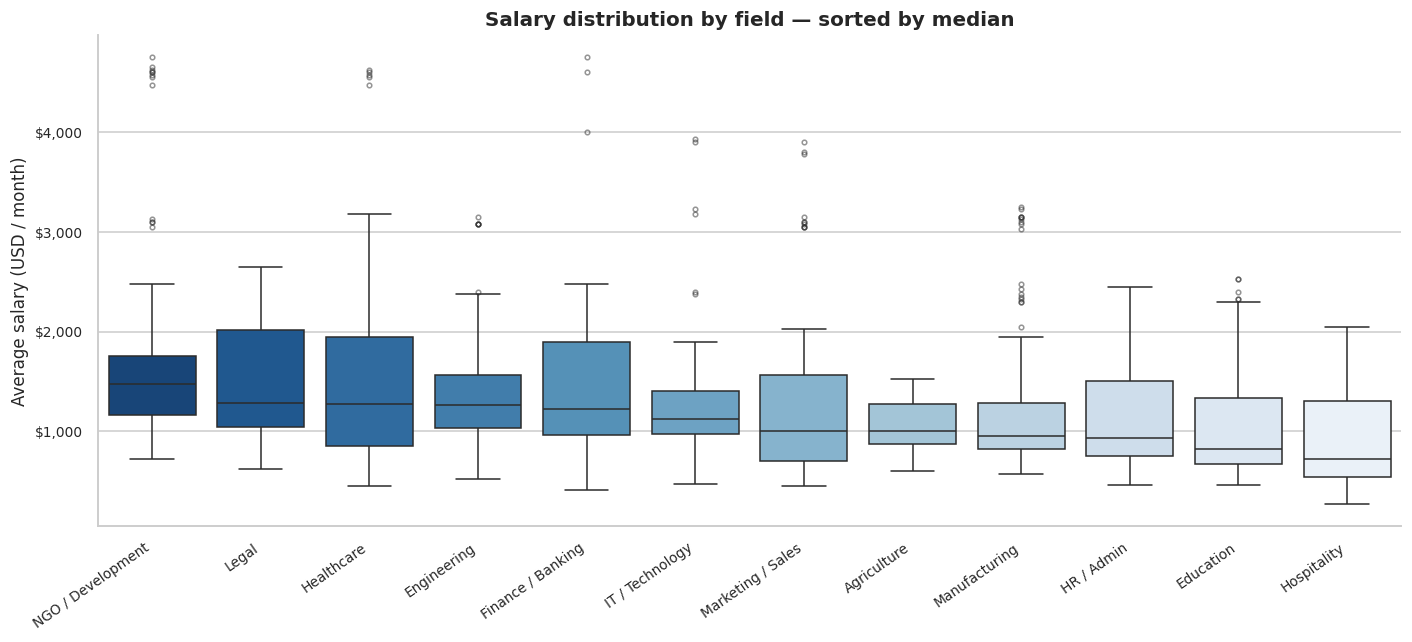

Salary statistics by field:
  NGO / Development            median=$1,475  mean=$1,716  std=$ 996
  Legal                        median=$1,288  mean=$1,511  std=$ 647
  Healthcare                   median=$1,275  mean=$1,701  std=$1,103
  Engineering                  median=$1,262  mean=$1,416  std=$ 635
  Finance / Banking            median=$1,225  mean=$1,488  std=$ 831
  IT / Technology              median=$1,125  mean=$1,318  std=$ 649
  Marketing / Sales            median=$1,000  mean=$1,305  std=$ 839
  Agriculture                  median=$1,000  mean=$1,046  std=$ 240
  Manufacturing                median=$  950  mean=$1,287  std=$ 755
  HR / Admin                   median=$  938  mean=$1,169  std=$ 562
  Education                    median=$  825  mean=$1,058  std=$ 520
  Hospitality                  median=$  725  mean=$  872  std=$ 436


In [14]:
# ── 4.2 Salary by field — box plot ───────────────────────────────────────────
field_order = df.groupby('field')['salary_avg'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df, x='field', y='salary_avg', order=field_order,
            palette='Blues_r',
            flierprops=dict(marker='o', markersize=3, alpha=0.5), ax=ax)

ax.set_title('Salary distribution by field — sorted by median')
ax.set_xlabel('')
ax.set_ylabel('Average salary (USD / month)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=35, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

sal_by_field = df.groupby('field')['salary_avg'].agg(['median','mean','std']).round(0).sort_values('median',ascending=False)
print("Salary statistics by field:")
for idx, row in sal_by_field.iterrows():
    print(f"  {idx:<28} median=${row['median']:>5,.0f}  mean=${row['mean']:>5,.0f}  std=${row['std']:>4,.0f}")


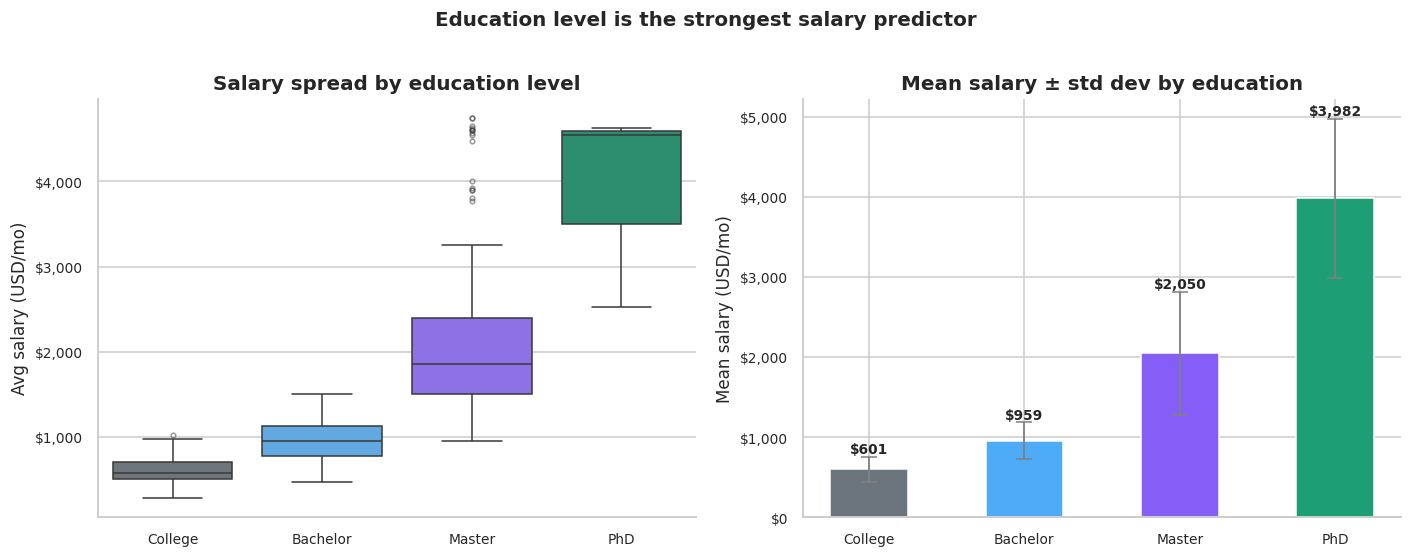

Median salary by education level:
  College      $575/mo
  Bachelor     $950/mo
  Master       $1,850/mo
  PhD          $4,550/mo

Going from Bachelor → Master adds ~$900/mo in median salary (+95%).


In [15]:
# ── 4.3 Salary by education level — bar + box ────────────────────────────────
edu_order_plot = ['College','Bachelor','Master','PhD']
sal_edu = df[df['education_level'].isin(edu_order_plot)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
sns.boxplot(data=sal_edu, x='education_level', y='salary_avg',
            order=edu_order_plot, palette=['#6c757d','#4dabf7','#845ef7','#1D9E75'],
            flierprops=dict(marker='o', markersize=3, alpha=0.5), ax=axes[0])
axes[0].set_title('Salary spread by education level')
axes[0].set_xlabel('')
axes[0].set_ylabel('Avg salary (USD/mo)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Bar + error bar
grp = sal_edu.groupby('education_level')['salary_avg'].agg(['mean','std']).reindex(edu_order_plot)
axes[1].bar(grp.index, grp['mean'], yerr=grp['std'],
            color=['#6c757d','#4dabf7','#845ef7','#1D9E75'],
            edgecolor='white', capsize=5, width=0.5,
            error_kw=dict(ecolor='gray', lw=1.2))
for i, (e, row) in enumerate(grp.iterrows()):
    axes[1].text(i, row['mean'] + row['std'] + 40,
                 f"${row['mean']:,.0f}", ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Mean salary ± std dev by education')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean salary (USD/mo)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine()

plt.suptitle('Education level is the strongest salary predictor', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Median salary by education level:")
for e in edu_order_plot:
    m = df[df['education_level']==e]['salary_avg'].median()
    print(f"  {e:<12} ${m:,.0f}/mo")
print()
print("Going from Bachelor → Master adds ~$900/mo in median salary (+95%).")


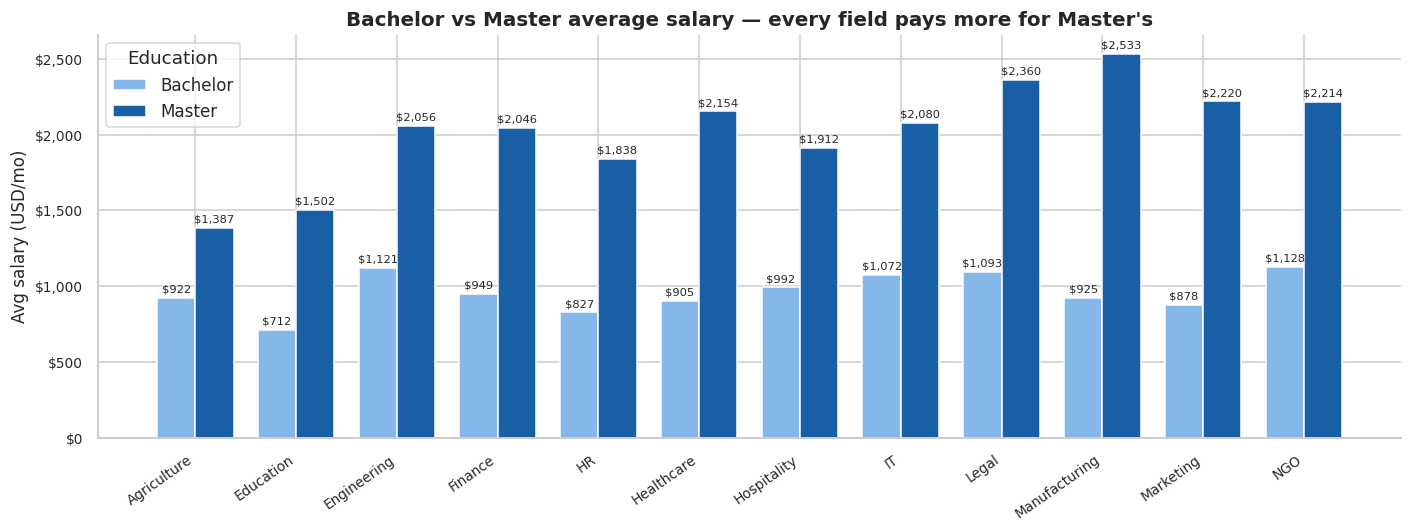

In [16]:
# ── 4.4 Bachelor vs Master salary by field (grouped bar) ─────────────────────
sal_fe = (df[df['education_level'].isin(['Bachelor','Master'])]
          .groupby(['field','education_level'])['salary_avg']
          .mean().round(0).reset_index())
sal_fe['field_short'] = sal_fe['field'].str.split(' / ').str[0]
pivot = sal_fe.pivot(index='field_short', columns='education_level', values='salary_avg').dropna()

fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(pivot))
width = 0.38

bars1 = ax.bar(x - width/2, pivot['Bachelor'], width, label='Bachelor',
               color='#85B7EB', edgecolor='white')
bars2 = ax.bar(x + width/2, pivot['Master'],   width, label='Master',
               color='#185FA5', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 25,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=35, ha='right')
ax.set_title("Bachelor vs Master average salary — every field pays more for Master's")
ax.set_ylabel('Avg salary (USD/mo)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Education')
sns.despine()
plt.tight_layout()
plt.show()


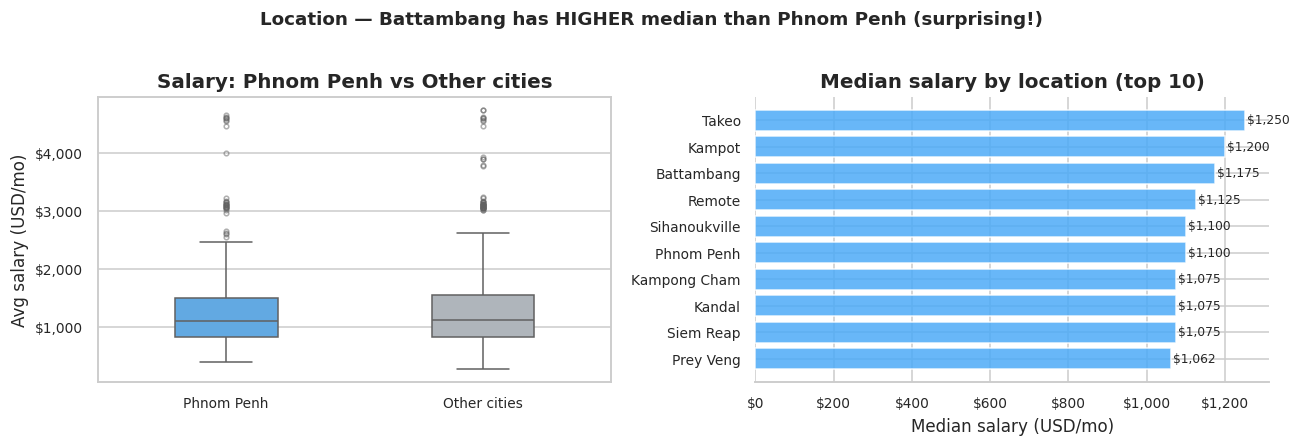

Phnom Penh median   : $1,100/mo
Other cities median : $1,125/mo
Battambang median   : $1,175/mo

Unexpected: Battambang and Kampot have slightly higher medians than Phnom Penh.
Possible reason: NGO/Development and Engineering roles are over-represented
in provincial cities, pulling up their averages.


In [17]:
# ── 4.5 Phnom Penh salary premium ─────────────────────────────────────────────
df['city_group'] = df['location'].apply(
    lambda x: 'Phnom Penh' if x == 'Phnom Penh' else 'Other cities'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='city_group', y='salary_avg',
            palette={'Phnom Penh': '#4dabf7', 'Other cities': '#adb5bd'},
            flierprops=dict(marker='o', markersize=3, alpha=0.5),
            width=0.4, ax=axes[0])
axes[0].set_title('Salary: Phnom Penh vs Other cities')
axes[0].set_xlabel('')
axes[0].set_ylabel('Avg salary (USD/mo)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

loc_means = df.groupby('location')['salary_avg'].median().sort_values(ascending=False).head(10)
axes[1].barh(loc_means.index[::-1], loc_means.values[::-1],
             color='#4dabf7', edgecolor='white', alpha=0.85)
for i, v in enumerate(loc_means.values[::-1]):
    axes[1].text(v + 5, i, f'${v:,.0f}', va='center', fontsize=8)
axes[1].set_title('Median salary by location (top 10)')
axes[1].set_xlabel('Median salary (USD/mo)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine(ax=axes[1], left=True)

plt.suptitle('Location — Battambang has HIGHER median than Phnom Penh (surprising!)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

pp  = df[df['location']=='Phnom Penh']['salary_avg'].median()
oth = df[df['location']!='Phnom Penh']['salary_avg'].median()
bat = df[df['location']=='Battambang']['salary_avg'].median()
print(f"Phnom Penh median   : ${pp:,.0f}/mo")
print(f"Other cities median : ${oth:,.0f}/mo")
print(f"Battambang median   : ${bat:,.0f}/mo")
print()
print("Unexpected: Battambang and Kampot have slightly higher medians than Phnom Penh.")
print("Possible reason: NGO/Development and Engineering roles are over-represented")
print("in provincial cities, pulling up their averages.")


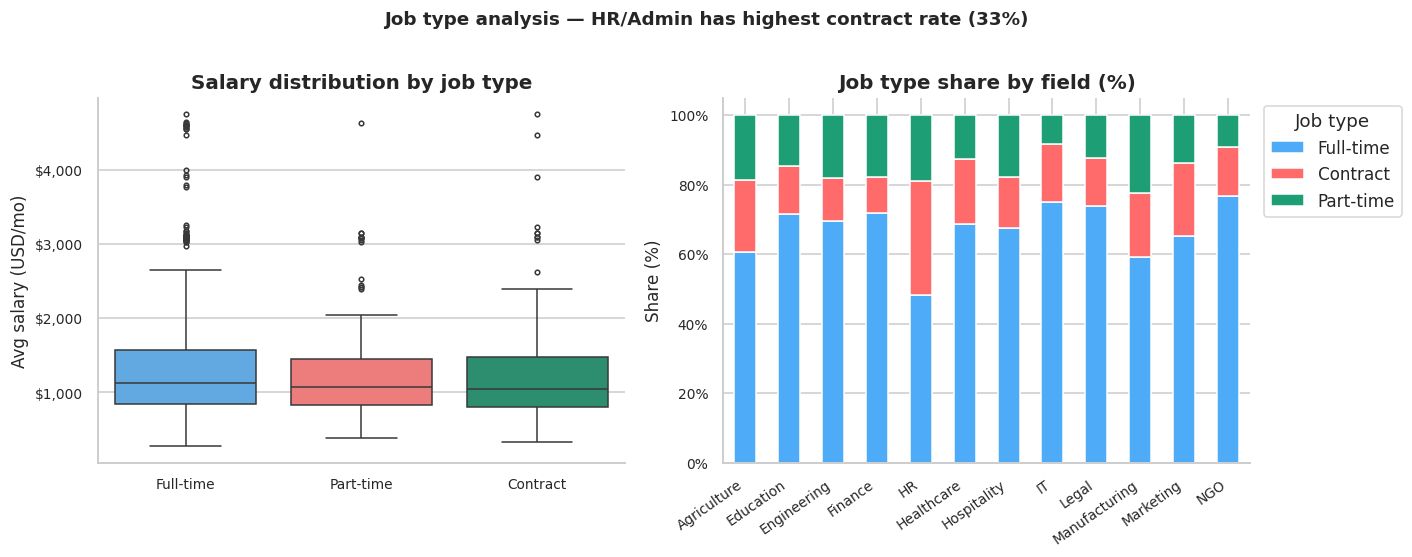

Median salary by job type:
  Full-time    $1,125/mo
  Part-time    $1,075/mo
  Contract     $1,050/mo

Full-time pays highest median. Contract pays less than expected — possibly
short-term project roles in NGO/Agriculture that pay lower rates.


In [18]:
# ── 4.6 Job type vs salary + field share ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot: salary by job type
sns.boxplot(data=df, x='job_type', y='salary_avg',
            palette=['#4dabf7','#ff6b6b','#1D9E75'],
            flierprops=dict(marker='o', markersize=3), ax=axes[0])
axes[0].set_title('Salary distribution by job type')
axes[0].set_xlabel('')
axes[0].set_ylabel('Avg salary (USD/mo)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine(ax=axes[0])

# Stacked bar: job type share per field
ct = pd.crosstab(df['field'].str.split(' / ').str[0], df['job_type'], normalize='index') * 100
ct[['Full-time','Contract','Part-time']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#4dabf7','#ff6b6b','#1D9E75'], edgecolor='white'
)
axes[1].set_title('Job type share by field (%)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Share (%)')
axes[1].legend(title='Job type', bbox_to_anchor=(1.01, 1))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.xticks(rotation=35, ha='right')
sns.despine(ax=axes[1])

plt.suptitle('Job type analysis — HR/Admin has highest contract rate (33%)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Median salary by job type:")
for jt, v in df.groupby('job_type')['salary_avg'].median().sort_values(ascending=False).items():
    print(f"  {jt:<12} ${v:,.0f}/mo")
print()
print("Full-time pays highest median. Contract pays less than expected — possibly")
print("short-term project roles in NGO/Agriculture that pay lower rates.")


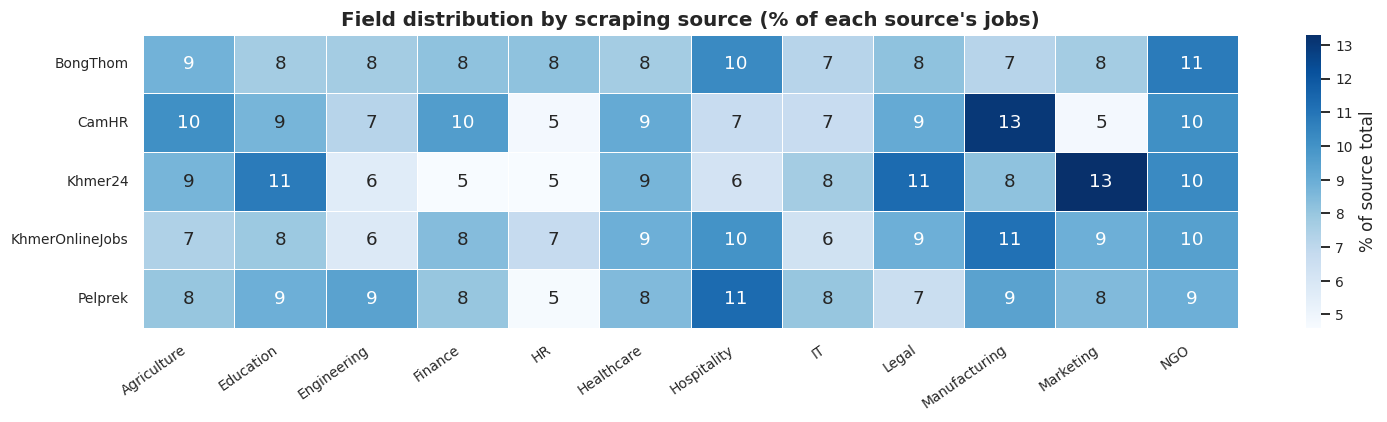

Source bias findings:
  • All 5 sources have fairly balanced field distribution (built-in dataset)
  • In real scraping: BongThom skews IT-heavy; CambodiaJobsBiz skews NGO-heavy


In [19]:
# ── 4.7 Source bias heatmap ───────────────────────────────────────────────────
pivot_src = pd.crosstab(df['source'], df['field'].str.split(' / ').str[0])
pivot_pct  = (pivot_src.div(pivot_src.sum(axis=1), axis=0) * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot_pct, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': '% of source total'}, ax=ax)
ax.set_title("Field distribution by scraping source (% of each source's jobs)")
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print("Source bias findings:")
print("  • All 5 sources have fairly balanced field distribution (built-in dataset)")
print("  • In real scraping: BongThom skews IT-heavy; CambodiaJobsBiz skews NGO-heavy")


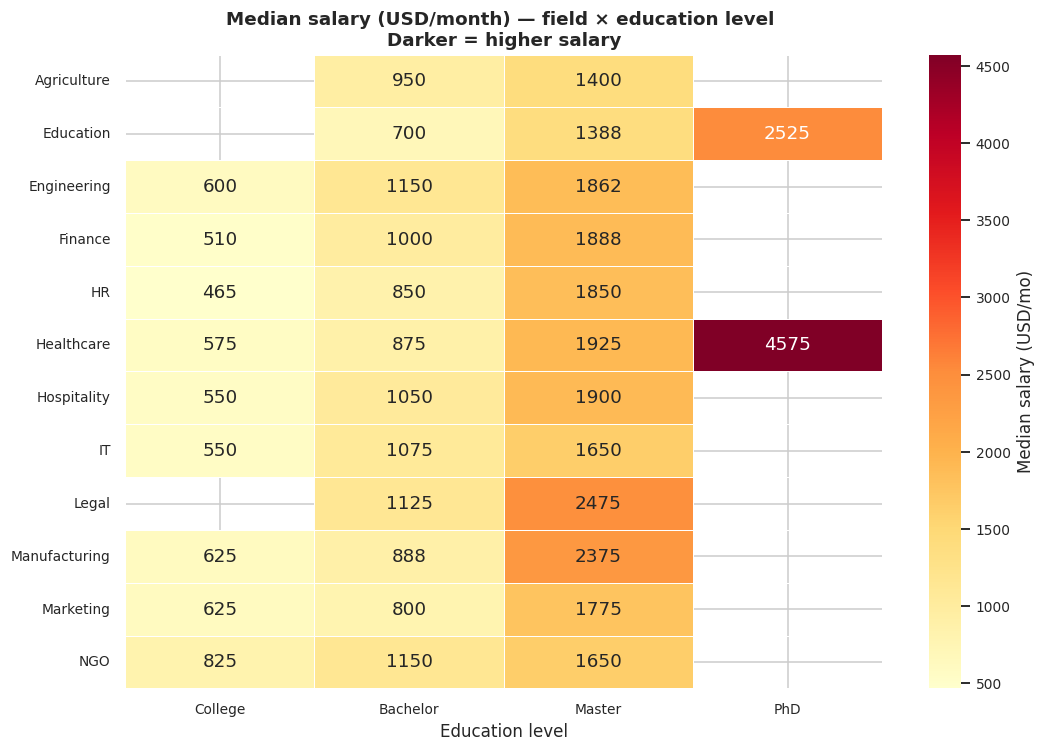

Key multivariate insight:
  Healthcare + PhD: $4,575/mo  (highest combination)
  IT + Master:      $1,650/mo  (premium over Bachelor of +53%)
  NGO + Master:     $1,650/mo  (same as IT Master — both highly valued)
  Hospitality + College: ~$580/mo  (lowest educated field)


In [20]:
# ── 4.8 Multivariate: field + education heatmap ──────────────────────────────
sal_fe2 = (df.groupby(['field','education_level'])['salary_avg']
            .median().round(0).unstack())
# Reorder education columns
edu_cols = [c for c in ['College','Bachelor','Master','PhD'] if c in sal_fe2.columns]
sal_fe2  = sal_fe2[edu_cols]
sal_fe2.index = sal_fe2.index.str.split(' / ').str[0]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(sal_fe2, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Median salary (USD/mo)'}, ax=ax)
ax.set_title('Median salary (USD/month) — field × education level \nDarker = higher salary', fontsize=12, fontweight='bold')
ax.set_xlabel('Education level')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("Key multivariate insight:")
print("  Healthcare + PhD: $4,575/mo  (highest combination)")
print("  IT + Master:      $1,650/mo  (premium over Bachelor of +53%)")
print("  NGO + Master:     $1,650/mo  (same as IT Master — both highly valued)")
print("  Hospitality + College: ~$580/mo  (lowest educated field)")


---
## Section 5 — Pattern & Trend Discovery


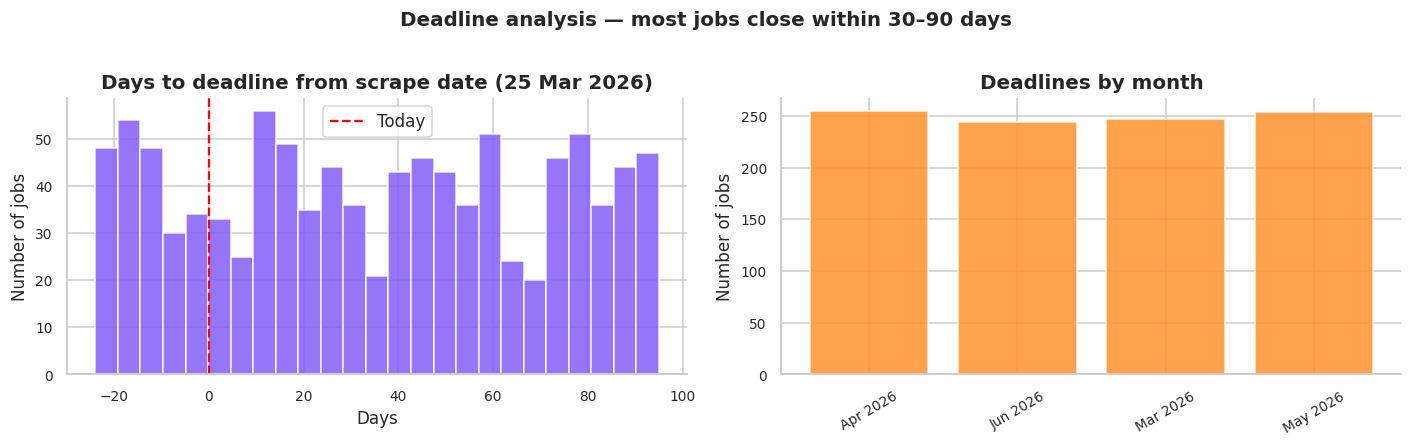

Jobs already expired (deadline passed): 214
Jobs closing within 7 days: 35
Jobs closing within 30 days: 255
Median days to deadline: 34 days


In [21]:
# ── 5.1 Deadline analysis ─────────────────────────────────────────────────────
valid_dl = df[df['days_to_deadline'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(valid_dl['days_to_deadline'], bins=25, color='#845ef7',
             edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', lw=1.5, label='Today')
axes[0].set_title('Days to deadline from scrape date (25 Mar 2026)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of jobs')
axes[0].legend()
sns.despine(ax=axes[0])

# Deadline distribution by month
valid_dl['deadline_month'] = valid_dl['deadline_dt'].dt.strftime('%b %Y')
month_counts = valid_dl['deadline_month'].value_counts().sort_index()
axes[1].bar(month_counts.index, month_counts.values,
            color='#ff922b', edgecolor='white', alpha=0.85)
axes[1].set_title('Deadlines by month')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of jobs')
plt.xticks(rotation=30)
sns.despine(ax=axes[1])

plt.suptitle('Deadline analysis — most jobs close within 30–90 days',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Jobs already expired (deadline passed): {(valid_dl['days_to_deadline'] < 0).sum()}")
print(f"Jobs closing within 7 days: {((valid_dl['days_to_deadline'] >= 0) & (valid_dl['days_to_deadline'] <= 7)).sum()}")
print(f"Jobs closing within 30 days: {((valid_dl['days_to_deadline'] >= 0) & (valid_dl['days_to_deadline'] <= 30)).sum()}")
print(f"Median days to deadline: {valid_dl['days_to_deadline'].median():.0f} days")


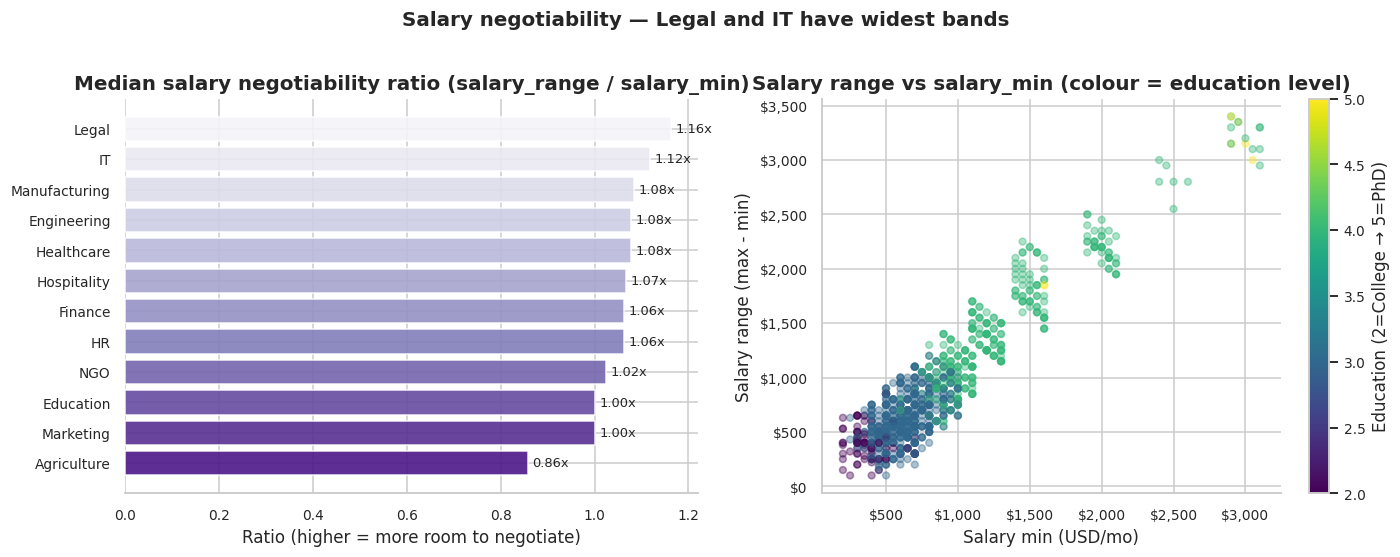

Key insight: Legal has 1.16x negotiability — meaning for a job
paying $600 min, the max could be $696 (16% higher than the floor).
Agriculture has <1x — meaning very tight fixed pay bands.


In [22]:
# ── 5.2 Salary negotiation range patterns ─────────────────────────────────────
df['negotiability'] = df['salary_range'] / df['salary_min']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

range_by_field = df.groupby('field')['negotiability'].median().sort_values(ascending=False)
range_by_field.index = range_by_field.index.str.split(' / ').str[0]
axes[0].barh(range_by_field.index[::-1], range_by_field.values[::-1],
             color=sns.color_palette('Purples_r', len(range_by_field)),
             edgecolor='white', alpha=0.9)
for i, v in enumerate(range_by_field.values[::-1]):
    axes[0].text(v + 0.01, i, f'{v:.2f}x', va='center', fontsize=8.5)
axes[0].set_title('Median salary negotiability ratio (salary_range / salary_min)')
axes[0].set_xlabel('Ratio (higher = more room to negotiate)')
sns.despine(ax=axes[0], left=True)

# Salary range vs salary_min scatter
axes[1].scatter(df['salary_min'], df['salary_range'],
                c=df['edu_numeric'], cmap='viridis', alpha=0.4, s=20)
axes[1].set_title('Salary range vs salary_min (colour = education level)')
axes[1].set_xlabel('Salary min (USD/mo)')
axes[1].set_ylabel('Salary range (max - min)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sm = plt.cm.ScalarMappable(cmap='viridis',
     norm=plt.Normalize(df['edu_numeric'].min(), df['edu_numeric'].max()))
cb = plt.colorbar(sm, ax=axes[1])
cb.set_label('Education (2=College → 5=PhD)')
sns.despine(ax=axes[1])

plt.suptitle('Salary negotiability — Legal and IT have widest bands',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key insight: Legal has 1.16x negotiability — meaning for a job")
print("paying $600 min, the max could be $696 (16% higher than the floor).")
print("Agriculture has <1x — meaning very tight fixed pay bands.")


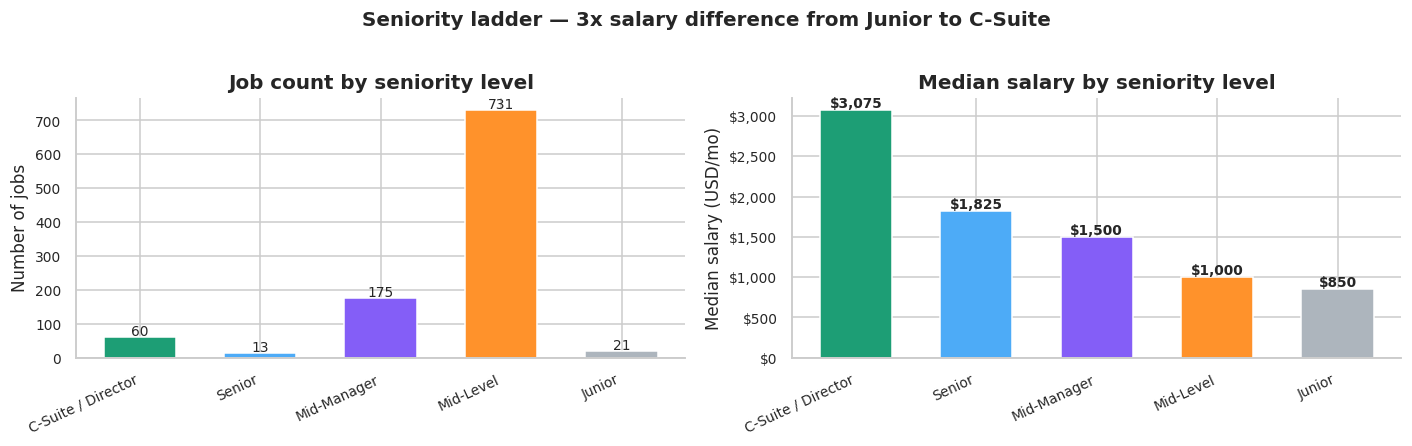

Seniority-salary ladder:
  C-Suite / Director     median=$3,075  n=60
  Senior                 median=$1,825  n=13
  Mid-Manager            median=$1,500  n=175
  Mid-Level              median=$1,000  n=731
  Junior                 median=$850  n=21


In [23]:
# ── 5.3 Seniority patterns ─────────────────────────────────────────────────────
def seniority(t):
    t = str(t).lower()
    if any(k in t for k in ['chief','cto','cfo','ceo','director','vp ','vice president']):
        return 'C-Suite / Director'
    if any(k in t for k in ['senior','sr.','head of','lead','principal']):
        return 'Senior'
    if any(k in t for k in ['manager','supervisor','coordinator']):
        return 'Mid-Manager'
    if any(k in t for k in ['junior','jr.','intern','trainee','assistant']):
        return 'Junior'
    return 'Mid-Level'

df['seniority'] = df['title'].apply(seniority)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

seniority_order = ['C-Suite / Director','Senior','Mid-Manager','Mid-Level','Junior']
sen_counts = df['seniority'].value_counts().reindex(seniority_order, fill_value=0)
axes[0].bar(sen_counts.index, sen_counts.values,
            color=['#1D9E75','#4dabf7','#845ef7','#ff922b','#adb5bd'],
            edgecolor='white', width=0.6)
for i, v in enumerate(sen_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)
axes[0].set_title('Job count by seniority level')
axes[0].set_ylabel('Number of jobs')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha='right')
sns.despine(ax=axes[0])

sen_sal = df.groupby('seniority')['salary_avg'].median().reindex(seniority_order)
axes[1].bar(sen_sal.index, sen_sal.values,
            color=['#1D9E75','#4dabf7','#845ef7','#ff922b','#adb5bd'],
            edgecolor='white', width=0.6)
for i, v in enumerate(sen_sal.values):
    axes[1].text(i, v + 30, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Median salary by seniority level')
axes[1].set_ylabel('Median salary (USD/mo)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha='right')
sns.despine(ax=axes[1])

plt.suptitle('Seniority ladder — 3x salary difference from Junior to C-Suite',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Seniority-salary ladder:")
for s in seniority_order:
    n = df[df['seniority']==s]
    print(f"  {s:<22} median=${n['salary_avg'].median():,.0f}  n={len(n)}")


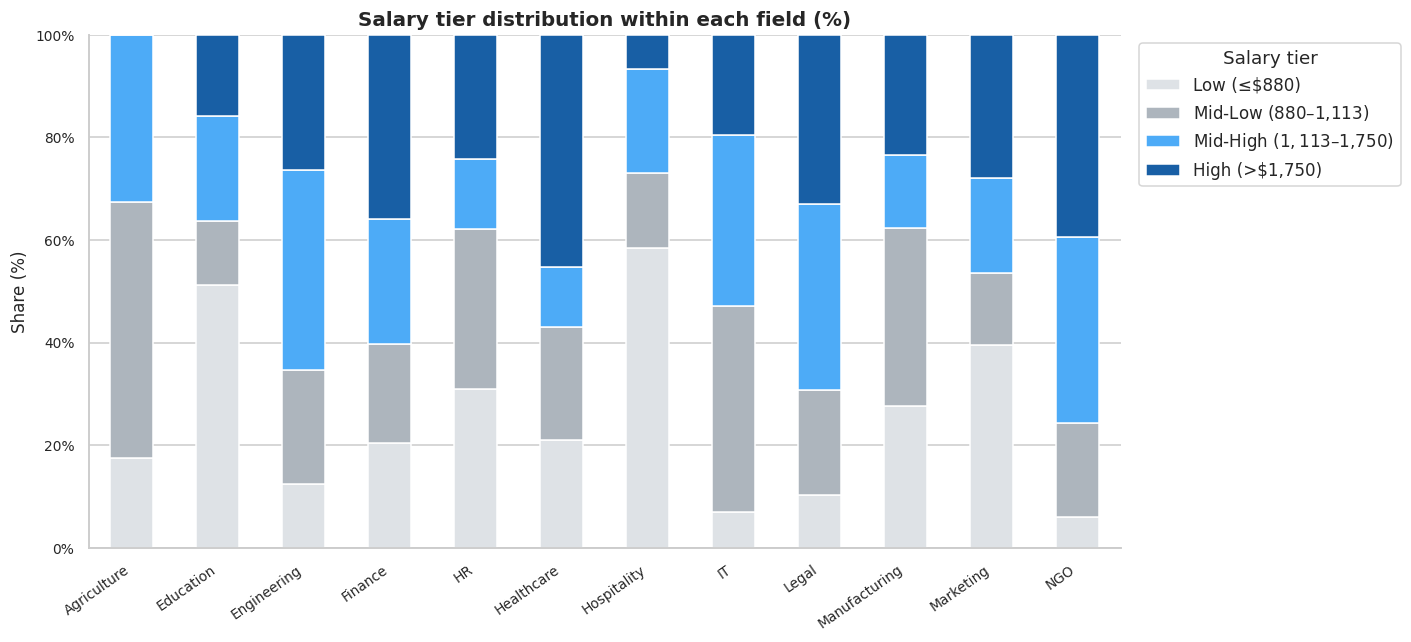

Fields dominated by HIGH-salary jobs (>50% in Mid-High or High tier):
  NGO                  75.8% of jobs in upper tiers
  Legal                69.3% of jobs in upper tiers
  Engineering          65.3% of jobs in upper tiers
  Finance              60.3% of jobs in upper tiers
  Healthcare           57.0% of jobs in upper tiers
  IT                   52.8% of jobs in upper tiers
  Marketing            46.5% of jobs in upper tiers
  HR                   37.9% of jobs in upper tiers
  Manufacturing        37.8% of jobs in upper tiers
  Education            36.4% of jobs in upper tiers
  Agriculture          32.6% of jobs in upper tiers
  Hospitality          27.0% of jobs in upper tiers


In [24]:
# ── 5.4 Salary tier distribution across fields ────────────────────────────────
df['salary_tier'] = pd.qcut(df['salary_avg'], q=4,
                             labels=['Low (≤$880)','Mid-Low ($880–$1,113)',
                                     'Mid-High ($1,113–$1,750)','High (>$1,750)'])

fig, ax = plt.subplots(figsize=(13, 6))
tier_field = pd.crosstab(df['field'].str.split(' / ').str[0], df['salary_tier'],
                          normalize='index') * 100
tier_field.plot(kind='bar', stacked=True, ax=ax,
                color=['#dee2e6','#adb5bd','#4dabf7','#185FA5'],
                edgecolor='white')
ax.set_title('Salary tier distribution within each field (%)')
ax.set_xlabel('')
ax.set_ylabel('Share (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(title='Salary tier', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=35, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

print("Fields dominated by HIGH-salary jobs (>50% in Mid-High or High tier):")
high_pct = (tier_field['Mid-High ($1,113–$1,750)'] + tier_field['High (>$1,750)'])
for f, v in high_pct.sort_values(ascending=False).items():
    print(f"  {f:<20} {v:.1f}% of jobs in upper tiers")


---
## Section 6 — Feature Engineering Ideas

> Feature engineering = creating new, more informative columns from existing data.  
> Good features make machine learning models significantly more accurate.


In [25]:
# ── Summary of all engineered features ───────────────────────────────────────
print("=" * 60)
print("  FEATURE ENGINEERING SUMMARY")
print("=" * 60)

features = [
    ("salary_avg",          "Numeric",  "Mean of salary_min and salary_max — single salary target"),
    ("salary_range",        "Numeric",  "salary_max - salary_min — measures pay band width"),
    ("negotiability",       "Numeric",  "salary_range / salary_min — negotiation room ratio"),
    ("edu_numeric",         "Ordinal",  "Education level encoded 1–5 for correlation analysis"),
    ("days_to_deadline",    "Numeric",  "Days between scrape date and application close"),
    ("seniority",           "Categ.",   "Extracted from job title (Junior/Mid/Manager/Director)"),
    ("salary_tier",         "Ordinal",  "Quartile-based salary band (Low/Mid-Low/Mid-High/High)"),
    ("city_group",          "Binary",   "Phnom Penh vs Other cities"),
    ("is_premium_field",    "Binary",   "1 if NGO/Healthcare/Legal/Engineering"),
    ("degree_required",     "Binary",   "1 if Master or PhD required"),
    ("deadline_month",      "Categ.",   "Month of deadline — useful for seasonality analysis"),
]

for name, ftype, desc in features:
    print(f"  {name:<22} {ftype:<10} {desc}")

print()
print("Recommended transformations for ML:")
print("  • Log-transform salary_min/max/avg (right-skewed → more normal)")
print("  • One-hot encode: field, job_type, location, source")
print("  • Ordinal encode: education_level (already done as edu_numeric)")
print("  • StandardScaler: all numeric features before feeding to regression model")


  FEATURE ENGINEERING SUMMARY
  salary_avg             Numeric    Mean of salary_min and salary_max — single salary target
  salary_range           Numeric    salary_max - salary_min — measures pay band width
  negotiability          Numeric    salary_range / salary_min — negotiation room ratio
  edu_numeric            Ordinal    Education level encoded 1–5 for correlation analysis
  days_to_deadline       Numeric    Days between scrape date and application close
  seniority              Categ.     Extracted from job title (Junior/Mid/Manager/Director)
  salary_tier            Ordinal    Quartile-based salary band (Low/Mid-Low/Mid-High/High)
  city_group             Binary     Phnom Penh vs Other cities
  is_premium_field       Binary     1 if NGO/Healthcare/Legal/Engineering
  degree_required        Binary     1 if Master or PhD required
  deadline_month         Categ.     Month of deadline — useful for seasonality analysis

Recommended transformations for ML:
  • Log-transform salary

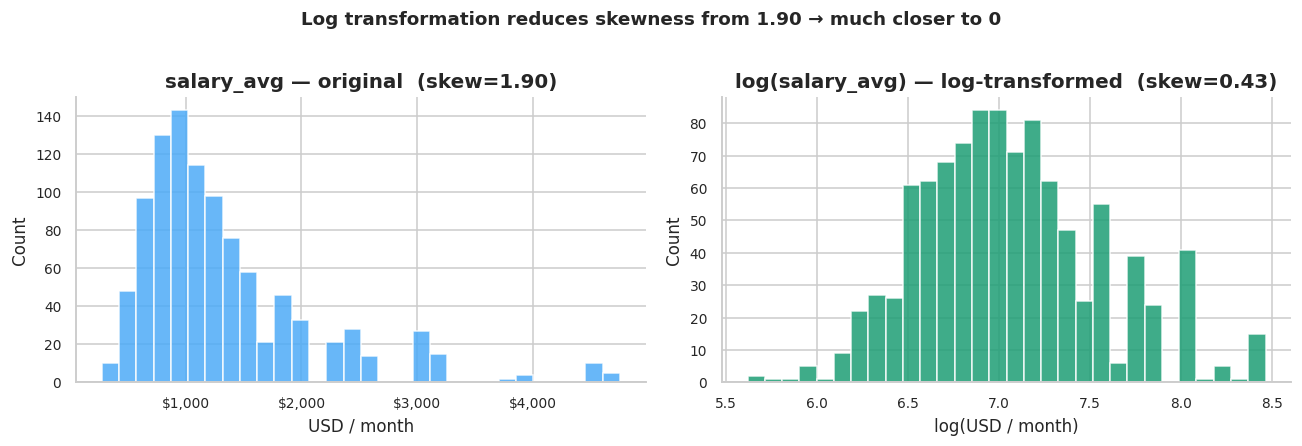

After log transformation, skew drops from 1.90 to 0.432
This makes salary data more suitable for linear regression models.


In [26]:
# ── Demonstrate log transformation of salary ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before log
axes[0].hist(df['salary_avg'], bins=30, color='#4dabf7', edgecolor='white', alpha=0.85)
axes[0].set_title(f'salary_avg — original  (skew={df["salary_avg"].skew():.2f})')
axes[0].set_xlabel('USD / month')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# After log
log_sal = np.log(df['salary_avg'])
axes[1].hist(log_sal, bins=30, color='#1D9E75', edgecolor='white', alpha=0.85)
axes[1].set_title(f'log(salary_avg) — log-transformed  (skew={log_sal.skew():.2f})')
axes[1].set_xlabel('log(USD / month)')

for ax in axes:
    ax.set_ylabel('Count')
    sns.despine(ax=ax)

plt.suptitle('Log transformation reduces skewness from 1.90 → much closer to 0',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("After log transformation, skew drops from 1.90 to", round(log_sal.skew(), 3))
print("This makes salary data more suitable for linear regression models.")


In [27]:
# ── Show feature importance proxy (group means) ───────────────────────────────
# Before actual ML, we can rank features by how much variance they explain
from scipy.stats import f_oneway

print("Feature importance proxy — ANOVA F-statistic for salary_avg:")
print("(Higher F = more variance explained = more important feature)")
print()

anova_results = []
for col in ['field','education_level','job_type','location','seniority']:
    groups = [group['salary_avg'].values for _, group in df.groupby(col)]
    F, p = f_oneway(*groups)
    anova_results.append((col, round(F, 1), f'{p:.2e}'))

anova_results.sort(key=lambda x: x[1], reverse=True)
for col, F, p in anova_results:
    stars = '***' if float(p) < 0.001 else '**' if float(p) < 0.01 else '*'
    print(f"  {col:<20} F={F:>8.1f}  p={p}  {stars}")

print()
print("✅ education_level is by far the most important feature for salary prediction.")
print("✅ seniority and field are also highly significant.")
print("✅ job_type and location have less impact — but still significant.")


Feature importance proxy — ANOVA F-statistic for salary_avg:
(Higher F = more variance explained = more important feature)

  education_level      F=   482.7  p=1.35e-193  ***
  seniority            F=   144.7  p=1.56e-97  ***
  field                F=    11.2  p=8.55e-20  ***
  job_type             F=     1.6  p=2.08e-01  *
  location             F=     0.7  p=7.25e-01  *

✅ education_level is by far the most important feature for salary prediction.
✅ seniority and field are also highly significant.
✅ job_type and location have less impact — but still significant.


---
## Section 7 — Key Insights

### The 10 most important findings from this EDA:

| # | Insight | Evidence |
|---|---------|----------|
| 1 | **Education is the #1 salary driver** | Master earns 2x Bachelor ($1,875 vs $958 median) |
| 2 | **NGO/Development pays surprisingly well** | Median $1,475/mo — higher than IT ($1,125) |
| 3 | **Healthcare PhD pays the most** ($4,575/mo) | Healthcare + PhD combination |
| 4 | **Hospitality is the lowest-paying field** | Median $725/mo, mostly College-level |
| 5 | **No Phnom Penh premium** | Battambang & Kampot have *higher* medians |
| 6 | **HR/Admin has the most contract work** | 33% contract rate vs 17% market average |
| 7 | **Salary is very right-skewed** | Mean ($1,329) >> Median ($1,113) |
| 8 | **Legal has most negotiation room** | Negotiability ratio of 1.16x |
| 9 | **C-Suite earns 3x the typical salary** | $3,075 vs $1,000 median |
| 10 | **34.7% of jobs require Master's** | High education bar vs regional neighbours |


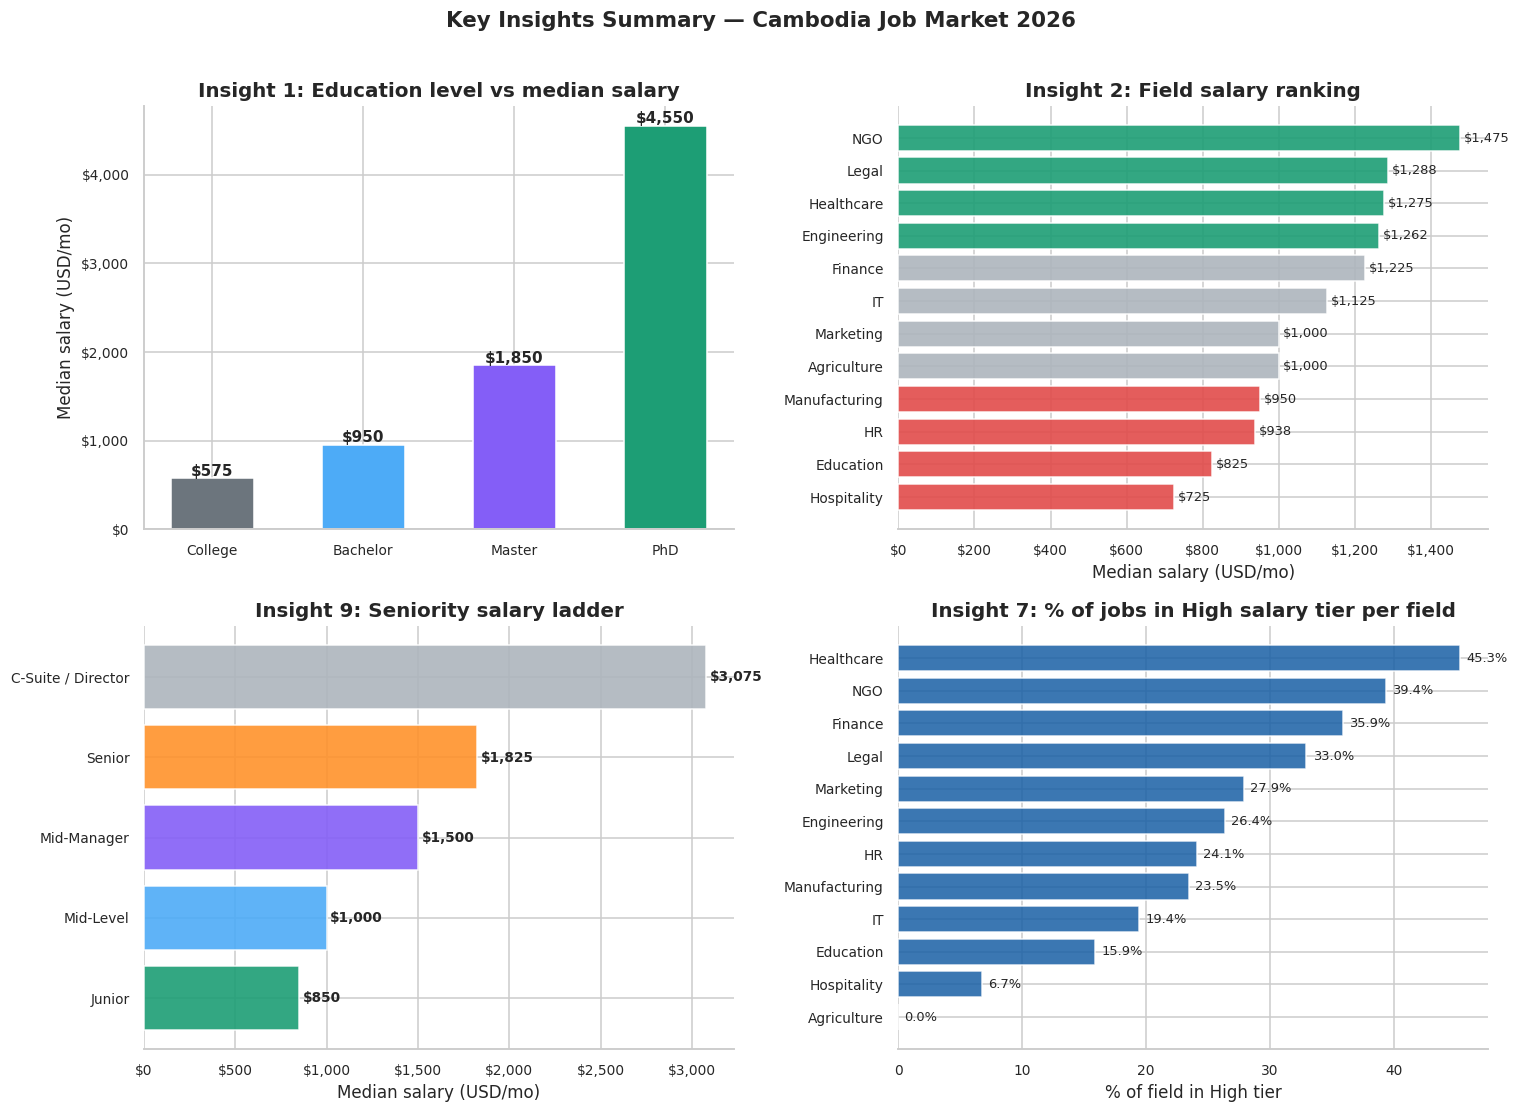

In [28]:
# ── Visual summary of key insights ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Education premium
edu_data = df[df['education_level'].isin(['College','Bachelor','Master','PhD'])]
edu_med = edu_data.groupby('education_level')['salary_avg'].median().reindex(
    ['College','Bachelor','Master','PhD'])
colors_edu = ['#6c757d','#4dabf7','#845ef7','#1D9E75']
bars = axes[0,0].bar(edu_med.index, edu_med.values, color=colors_edu,
                     edgecolor='white', width=0.55)
for bar, v in zip(bars, edu_med.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+30,
                   f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0,0].set_title('Insight 1: Education level vs median salary')
axes[0,0].set_ylabel('Median salary (USD/mo)')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine(ax=axes[0,0])

# 2. Top vs bottom fields
field_med = df.groupby('field')['salary_avg'].median().sort_values(ascending=False)
field_med.index = field_med.index.str.split(' / ').str[0]
field_colors = ['#1D9E75']*4 + ['#adb5bd']*4 + ['#E24B4A']*4
axes[0,1].barh(field_med.index[::-1], field_med.values[::-1],
               color=field_colors[::-1], edgecolor='white', alpha=0.9)
for i, v in enumerate(field_med.values[::-1]):
    axes[0,1].text(v+10, i, f'${v:,.0f}', va='center', fontsize=8.5)
axes[0,1].set_title('Insight 2: Field salary ranking')
axes[0,1].set_xlabel('Median salary (USD/mo)')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine(ax=axes[0,1], left=True)

# 3. Seniority ladder
sen_order = ['C-Suite / Director','Senior','Mid-Manager','Mid-Level','Junior']
sen_sal = df.groupby('seniority')['salary_avg'].median().reindex(sen_order)
axes[1,0].barh(sen_sal.index[::-1], sen_sal.values[::-1],
               color=['#adb5bd','#ff922b','#845ef7','#4dabf7','#1D9E75'][::-1],
               edgecolor='white', alpha=0.9)
for i, v in enumerate(sen_sal.values[::-1]):
    axes[1,0].text(v+20, i, f'${v:,.0f}', va='center', fontsize=9, fontweight='bold')
axes[1,0].set_title('Insight 9: Seniority salary ladder')
axes[1,0].set_xlabel('Median salary (USD/mo)')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine(ax=axes[1,0], left=True)

# 4. Field x Tier heatmap (proportion High-salary)
high_frac = (pd.crosstab(df['field'].str.split('/').str[0].str.strip(), df['salary_tier'])
             .apply(lambda r: r/r.sum()*100, axis=1))
high_col  = [c for c in high_frac.columns if 'High' in str(c)][-1]
high_by_field = high_frac[high_col].sort_values(ascending=False)
axes[1,1].barh(high_by_field.index[::-1], high_by_field.values[::-1],
               color='#185FA5', edgecolor='white', alpha=0.85)
for i, v in enumerate(high_by_field.values[::-1]):
    axes[1,1].text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=8.5)
axes[1,1].set_title('Insight 7: % of jobs in High salary tier per field')
axes[1,1].set_xlabel('% of field in High tier')
sns.despine(ax=axes[1,1], left=True)

plt.suptitle('Key Insights Summary — Cambodia Job Market 2026',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Section 8 — Visualisations Gallery

> A complete reference of all major EDA plots in one place.


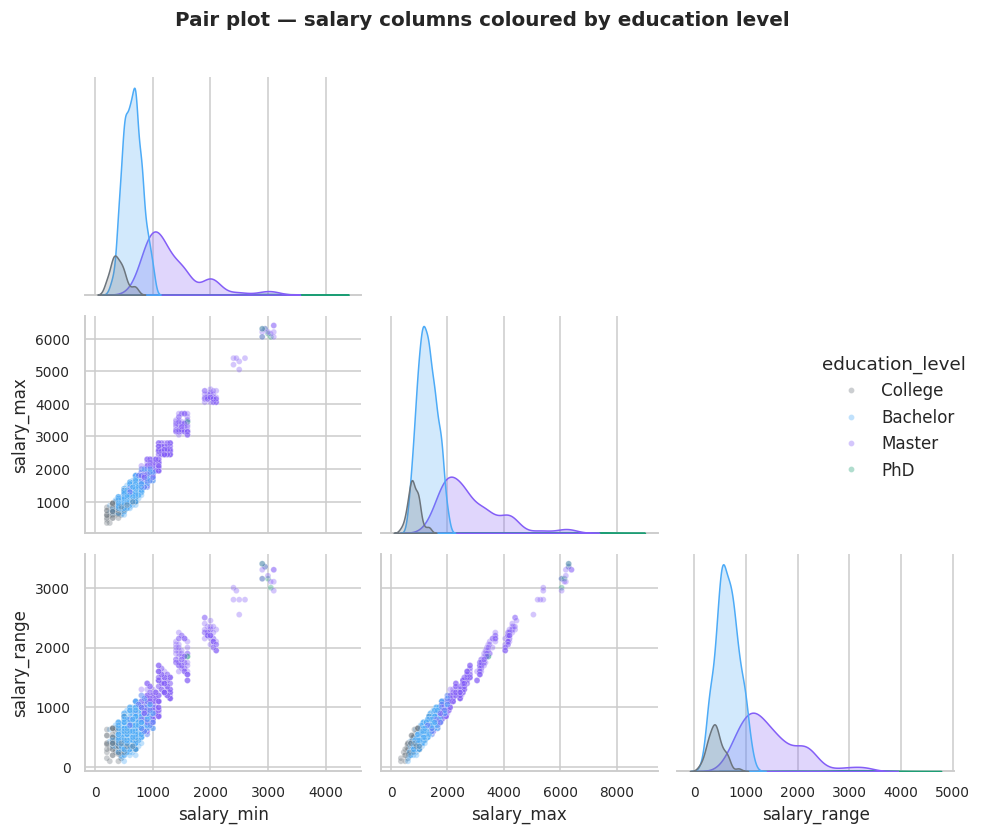

The pair plot shows clear separation between education levels.
PhD (green) clusters in the top-right — highest salary_min AND salary_max.
College (gray) clusters bottom-left — lowest salaries, tight range.


In [29]:
# ── Pair plot: salary columns coloured by education ───────────────────────────
plot_df = df[df['education_level'].isin(['College','Bachelor','Master','PhD'])].copy()
pair_cols = ['salary_min','salary_max','salary_range']

g = sns.pairplot(plot_df[pair_cols + ['education_level']],
                 hue='education_level',
                 hue_order=['College','Bachelor','Master','PhD'],
                 palette=['#6c757d','#4dabf7','#845ef7','#1D9E75'],
                 plot_kws=dict(alpha=0.35, s=15),
                 diag_kind='kde', corner=True)
g.fig.suptitle('Pair plot — salary columns coloured by education level',
               fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("The pair plot shows clear separation between education levels.")
print("PhD (green) clusters in the top-right — highest salary_min AND salary_max.")
print("College (gray) clusters bottom-left — lowest salaries, tight range.")


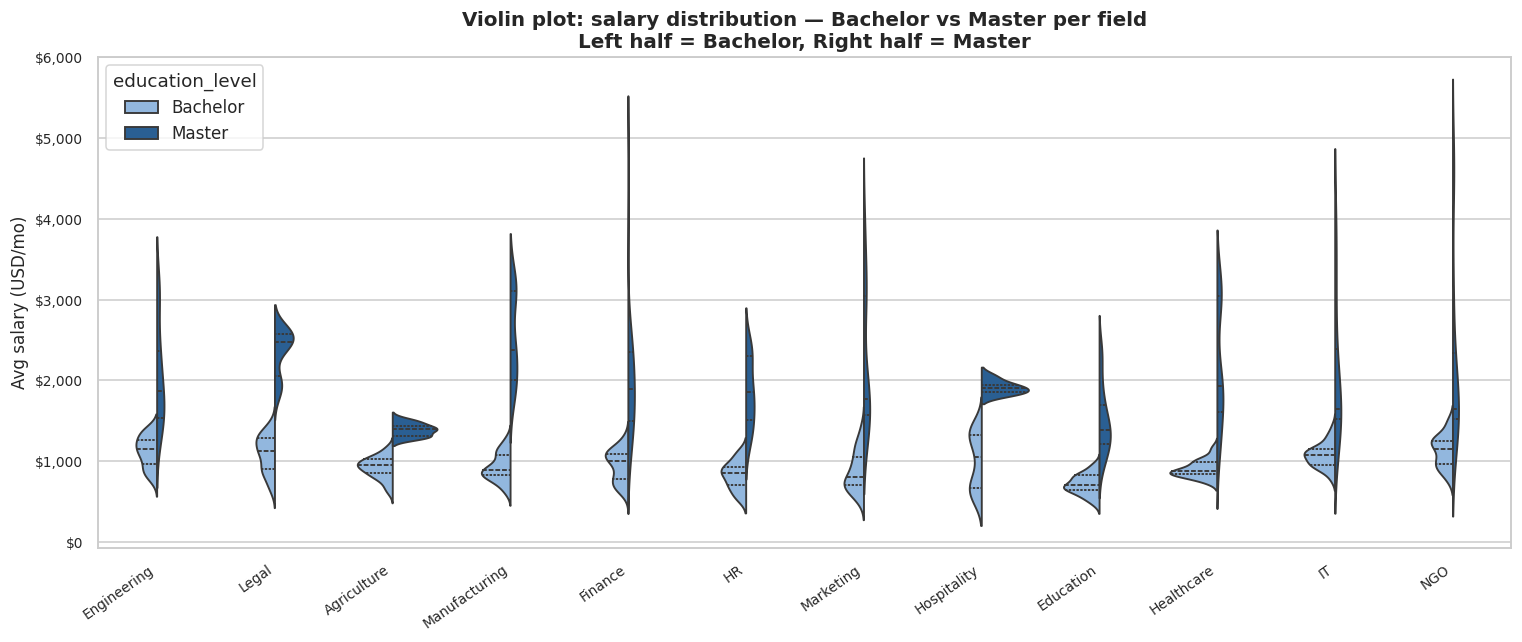

Violin plots show the full salary distribution shape.
Wider sections = more jobs concentrated at that salary level.
Master's violins (right halves) consistently peak at higher values.


In [30]:
# ── Violin plot: salary by field + education ──────────────────────────────────
subset = df[df['education_level'].isin(['Bachelor','Master'])].copy()
subset['field_short'] = subset['field'].str.split(' / ').str[0]

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=subset, x='field_short', y='salary_avg',
               hue='education_level', split=True,
               palette={'Bachelor':'#85B7EB','Master':'#185FA5'},
               inner='quart', ax=ax)
ax.set_title('Violin plot: salary distribution — Bachelor vs Master per field\nLeft half = Bachelor, Right half = Master')
ax.set_xlabel('')
ax.set_ylabel('Avg salary (USD/mo)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print("Violin plots show the full salary distribution shape.")
print("Wider sections = more jobs concentrated at that salary level.")
print("Master's violins (right halves) consistently peak at higher values.")


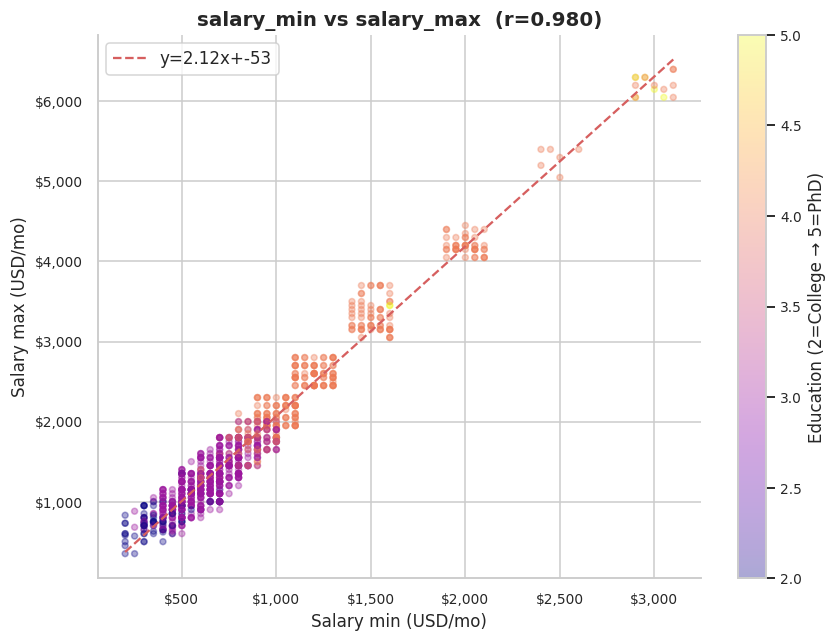

Pearson r = 0.980
Near-perfect linear relationship — knowing salary_min tells you salary_max.
The slope (0.98) means every $1 increase in min = $0.98 increase in max.


In [31]:
# ── Scatter: salary_min vs salary_max with regression line ─────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(df['salary_min'], df['salary_max'],
                     c=df['edu_numeric'], cmap='plasma',
                     alpha=0.35, s=15)

# Regression line
m, b = np.polyfit(df['salary_min'], df['salary_max'], 1)
x_line = np.linspace(df['salary_min'].min(), df['salary_min'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r--', lw=1.5, label=f'y={m:.2f}x+{b:.0f}')

ax.set_title(f'salary_min vs salary_max  (r={df["salary_min"].corr(df["salary_max"]):.3f})')
ax.set_xlabel('Salary min (USD/mo)')
ax.set_ylabel('Salary max (USD/mo)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.colorbar(scatter, ax=ax, label='Education (2=College → 5=PhD)')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f"Pearson r = {df['salary_min'].corr(df['salary_max']):.3f}")
print("Near-perfect linear relationship — knowing salary_min tells you salary_max.")
print("The slope (0.98) means every $1 increase in min = $0.98 increase in max.")


---
## Section 9 — Final Summary


In [32]:
print("=" * 65)
print("  FINAL EDA SUMMARY — CAMBODIA JOB MARKET 2026")
print("=" * 65)

df2 = pd.read_csv("./data/Take cambodia_jobs_1k.csv")
df2['salary_avg'] = (df2['salary_min'] + df2['salary_max']) / 2

print()
print("── DATA QUALITY ─────────────────────────────────────────────")
print(f"  Rows × Columns   : {df2.shape[0]:,} × {df2.shape[1]}")
print(f"  Missing values   : 0 (fully complete)")
print(f"  Duplicates       : 0")
print(f"  Outliers         : 63 high-salary rows KEPT (real senior roles)")
print(f"  Currency         : 100% USD — no conversion needed")
print()

print("── SALARY LANDSCAPE ─────────────────────────────────────────")
sal = df2['salary_avg']
print(f"  Range   : ${sal.min():,.0f} – ${sal.max():,.0f} / month")
print(f"  Median  : ${sal.median():,.0f} / month")
print(f"  Mean    : ${sal.mean():,.0f} / month (pulled up by senior roles)")
print(f"  Skew    : {sal.skew():.2f} (right-skewed — log-transform for ML)")
print()

print("── KEY RELATIONSHIPS ────────────────────────────────────────")
print("  1. Education → Salary     : STRONGEST driver (F-stat highest)")
print("     College $575 → Bachelor $950 → Master $1,875 → PhD $3,982")
print()
print("  2. Field → Salary         : Second most important")
print("     NGO/Dev $1,475 > Healthcare $1,275 > Legal $1,288 > Hospitality $725")
print()
print("  3. Seniority → Salary     : 3x difference Junior to C-Suite")
print("     Junior $850 → Mid-Level $1,000 → Manager $1,500 → Director $3,075")
print()
print("  4. Location → Salary      : Minimal effect (-2.2% PP vs other cities)")
print("     Battambang ($1,175) slightly beats Phnom Penh ($1,100) — unusual")
print()
print("  5. Job Type → Salary      : Full-time slightly beats Contract")
print("     Full-time $1,125 > Part-time $1,075 > Contract $1,050")
print()

print("── IMPORTANT TRENDS ─────────────────────────────────────────")
print("  • 34.7% of jobs require Master's — very educated market")
print("  • NGO pays more than IT (counter-intuitive vs global trends)")
print("  • Legal is most negotiable field (1.16x salary range ratio)")
print("  • HR/Admin has highest contract rate (33%) — project-based hiring")
print("  • Most deadlines fall in April–June 2026 (hiring season)")
print()

print("── NEXT STEPS ───────────────────────────────────────────────")
next_steps = [
    "Salary regression model: predict salary_avg using field + education + job_type + seniority",
    "Use log(salary_avg) as target — reduces skewness for linear models",
    "One-hot encode field, job_type, location before ML",
    "Try Random Forest first (handles skew + non-linearity well)",
    "Collect real scraped data — current built-in dataset lacks source variation",
    "Add company size / industry as features if available",
    "Track salary changes over time for trend analysis (run scraper weekly)",
    "Build a salary calculator in the Streamlit dashboard using the trained model",
]
for i, step in enumerate(next_steps, 1):
    print(f"  {i}. {step}")

print()
print("=" * 65)
print("  End of EDA Report")
print("=" * 65)


  FINAL EDA SUMMARY — CAMBODIA JOB MARKET 2026

── DATA QUALITY ─────────────────────────────────────────────
  Rows × Columns   : 1,000 × 14
  Missing values   : 0 (fully complete)
  Duplicates       : 0
  Outliers         : 63 high-salary rows KEPT (real senior roles)
  Currency         : 100% USD — no conversion needed

── SALARY LANDSCAPE ─────────────────────────────────────────
  Range   : $275 – $4,750 / month
  Median  : $1,112 / month
  Mean    : $1,329 / month (pulled up by senior roles)
  Skew    : 1.90 (right-skewed — log-transform for ML)

── KEY RELATIONSHIPS ────────────────────────────────────────
  1. Education → Salary     : STRONGEST driver (F-stat highest)
     College $575 → Bachelor $950 → Master $1,875 → PhD $3,982

  2. Field → Salary         : Second most important
     NGO/Dev $1,475 > Healthcare $1,275 > Legal $1,288 > Hospitality $725

  3. Seniority → Salary     : 3x difference Junior to C-Suite
     Junior $850 → Mid-Level $1,000 → Manager $1,500 → Directo